# TP — Clasificación de Imágenes con Dataset Público

## Clasificación de flores usando CNN base y Transfer Learning

Este notebook resuelve la actividad completa utilizando un dataset público disponible directamente desde **TensorFlow Datasets**.

No se requiere descargar archivos a la computadora ni usar credenciales de Kaggle. El dataset se carga en el entorno temporal de Google Colab.

**Dataset utilizado:** `tf_flowers`  
**Fuente:** TensorFlow Datasets  
**Problema:** clasificación multiclase de imágenes de flores  
**Clases:** daisy, dandelion, roses, sunflowers, tulips  


## 1. Introducción del problema y del dataset

El objetivo es entrenar y evaluar modelos de clasificación de imágenes capaces de reconocer el tipo de flor presente en una imagen.

Se trabajará con el dataset público **TF Flowers**, que contiene imágenes de flores organizadas en 5 clases:

- Daisy
- Dandelion
- Roses
- Sunflowers
- Tulips

Se implementarán dos enfoques:

1. **Modelo A:** una CNN simple entrenada desde cero.
2. **Modelo B:** un modelo de Transfer Learning basado en MobileNetV2 preentrenado con ImageNet.

Finalmente, ambos modelos serán comparados en el conjunto de test mediante accuracy, precision, recall, F1-score y matriz de confusión.


In [ ]:
# Instalación de librerías necesarias
# En Colab normalmente ya están instaladas.
!pip install -q tensorflow tensorflow-datasets scikit-learn seaborn

In [ ]:
# Importación de librerías

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Carga y exploración inicial

Se carga el dataset directamente desde TensorFlow Datasets.

La partición será:

- 70% entrenamiento
- 15% validación
- 15% test

Esta división se realiza directamente al cargar el dataset.


In [ ]:
# Carga del dataset

(train_raw, val_raw, test_raw), info = tfds.load(
    "tf_flowers",
    split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
    as_supervised=True,
    with_info=True,
    shuffle_files=True
)

class_names = info.features["label"].names
num_classes = len(class_names)

print("Nombre del dataset:", info.name)
print("Cantidad total de imágenes:", info.splits["train"].num_examples)
print("Clases:", class_names)
print("Cantidad de clases:", num_classes)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.SVUA0S_3.0.1/tf_flowers-train.tfrecord-[0-9][0-9][0-…

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.
Nombre del dataset: tf_flowers
Cantidad total de imágenes: 3670
Clases: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
Cantidad de clases: 5


In [ ]:
# Función para contar imágenes por clase

def count_classes(ds, class_names):
    counts = np.zeros(len(class_names), dtype=int)
    for _, label in tfds.as_numpy(ds):
        counts[label] += 1
    return pd.DataFrame({
        "clase": class_names,
        "cantidad": counts
    })

train_counts = count_classes(train_raw, class_names)
val_counts = count_classes(val_raw, class_names)
test_counts = count_classes(test_raw, class_names)

counts_table = train_counts.copy()
counts_table = counts_table.rename(columns={"cantidad": "train"})
counts_table["valid"] = val_counts["cantidad"]
counts_table["test"] = test_counts["cantidad"]
counts_table["total"] = counts_table[["train", "valid", "test"]].sum(axis=1)

counts_table

,clase,train,valid,test,total
0,dandelion,639,147,112,898
1,daisy,445,93,95,633
2,tulips,531,134,134,799
3,sunflowers,496,101,102,699
4,roses,458,76,107,641


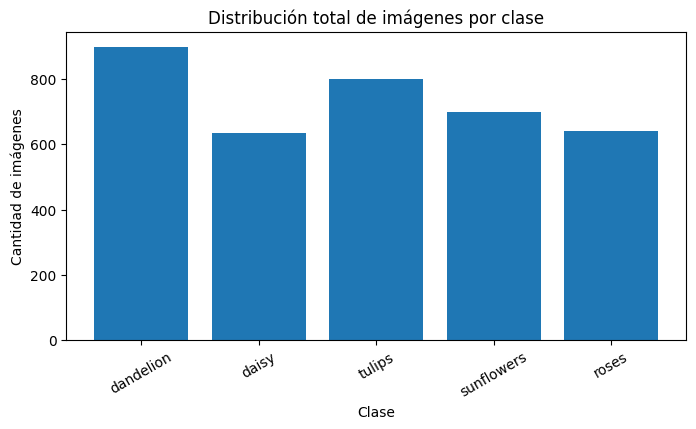

In [ ]:
# Distribución por clase

plt.figure(figsize=(8, 4))
plt.bar(counts_table["clase"], counts_table["total"])
plt.title("Distribución total de imágenes por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=30)
plt.show()

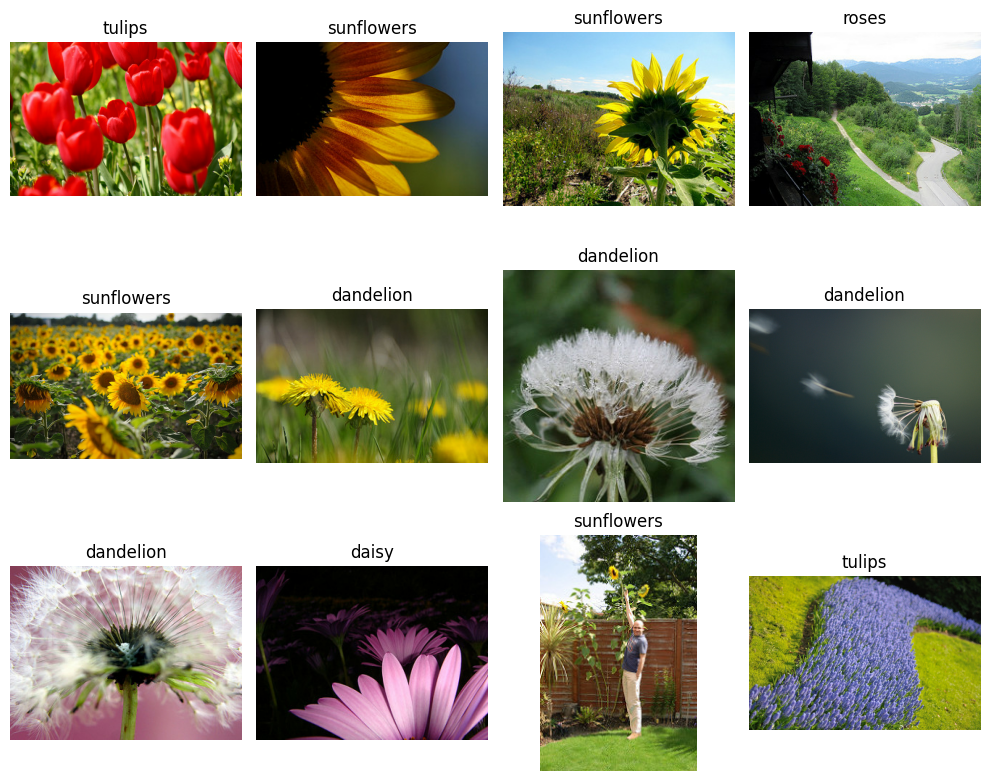

In [ ]:
# Visualización de ejemplos

plt.figure(figsize=(10, 8))

for i, (image, label) in enumerate(train_raw.take(12)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(class_names[int(label)])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Preprocesamiento y partición de datos

Las imágenes se redimensionan a un tamaño fijo de **224 × 224 píxeles**.

Para el modelo CNN base se normalizan los píxeles al rango `[0, 1]`.

También se aplica **data augmentation** solamente sobre el conjunto de entrenamiento:

- Rotación aleatoria
- Zoom aleatorio
- Flip horizontal


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_image(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = (
    train_raw
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .shuffle(1000, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_raw
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_raw
    .map(preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
], name="data_augmentation")

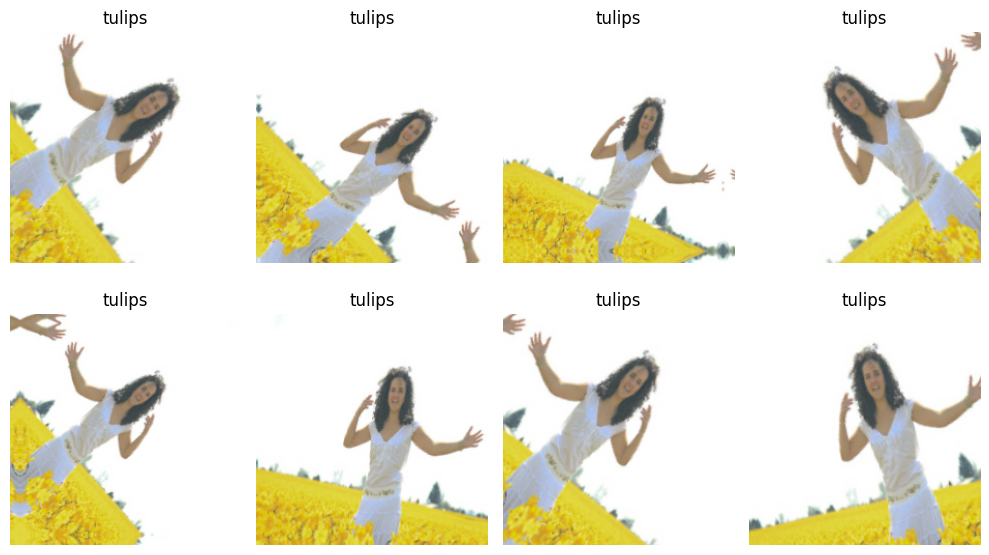

In [ ]:
# Ejemplo de data augmentation

for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]
    break

plt.figure(figsize=(10, 6))
for i in range(8):
    augmented_image = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
    plt.subplot(2, 4, i + 1)
    plt.imshow(augmented_image[0])
    plt.title(class_names[int(sample_label)])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Entrenamiento del Modelo A: CNN base

Se implementa una red convolucional simple desde cero.

Este modelo sirve como línea de base para comparar contra el modelo preentrenado.


In [ ]:
model_a = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax")
])

model_a.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS_A = 5

history_a = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_A
)

Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.5578 - loss: 1.1083 - val_accuracy: 0.6007 - val_loss: 0.9873
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 174s 2s/step - accuracy: 0.5921 - loss: 1.0333 - val_accuracy: 0.6298 - val_loss: 0.9495
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.6061 - loss: 0.9914 - val_accuracy: 0.6243 - val_loss: 0.9637
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.6240 - loss: 0.9599 - val_accuracy: 0.6243 - val_loss: 0.9021
Epoch 5/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.6384 - loss: 0.9274 - val_accuracy: 0.6443 - val_loss: 0.9080


## 5. Entrenamiento del Modelo B: Transfer Learning con MobileNetV2

Se utiliza **MobileNetV2** preentrenado con ImageNet.

Primero se congela la base convolucional y se entrena solamente el clasificador agregado al final.


In [ ]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = layers.Lambda(lambda img: preprocess_input(img * 255.0))(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_b = models.Model(inputs, outputs)

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_b.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS_B = 5

history_b = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_B
)

Epoch 1/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.5337 - loss: 1.2064 - val_accuracy: 0.7441 - val_loss: 0.7465
Epoch 2/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7462 - loss: 0.6983 - val_accuracy: 0.8004 - val_loss: 0.5821
Epoch 3/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 93s 1s/step - accuracy: 0.7844 - loss: 0.5839 - val_accuracy: 0.8367 - val_loss: 0.4982
Epoch 4/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.8241 - loss: 0.4939 - val_accuracy: 0.8421 - val_loss: 0.4437
Epoch 5/5
81/81 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.8392 - loss: 0.4563 - val_accuracy: 0.8494 - val_loss: 0.4199


### Ajuste fino

Para mejorar el desempeño, se descongelan las últimas capas de MobileNetV2 y se continúa el entrenamiento con una tasa de aprendizaje menor.


In [ ]:
# Fine tuning opcional

base_model.trainable = True

# Se congelan las primeras capas y se ajustan las últimas
fine_tune_at = 100

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS_FINE = 4

history_b_fine = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE
)

Epoch 1/4
81/81 ━━━━━━━━━━━━━━━━━━━━ 133s 2s/step - accuracy: 0.7314 - loss: 0.7295 - val_accuracy: 0.8494 - val_loss: 0.4171
Epoch 2/4
81/81 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.8128 - loss: 0.5157 - val_accuracy: 0.8548 - val_loss: 0.4024
Epoch 3/4
81/81 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.8392 - loss: 0.4485 - val_accuracy: 0.8621 - val_loss: 0.3781
Epoch 4/4
81/81 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8568 - loss: 0.4023 - val_accuracy: 0.8711 - val_loss: 0.3538


## 6. Gráficas de entrenamiento

Se grafican loss y accuracy para entrenamiento y validación.


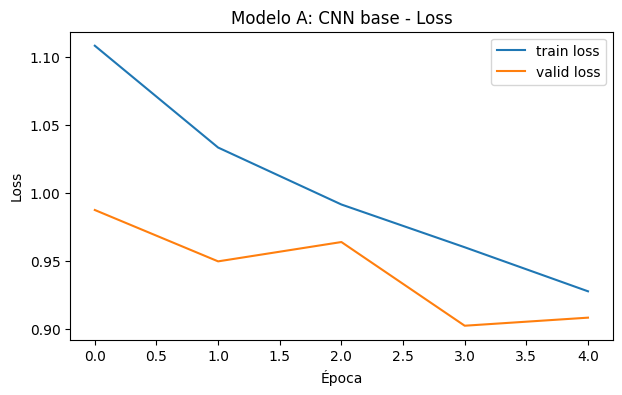

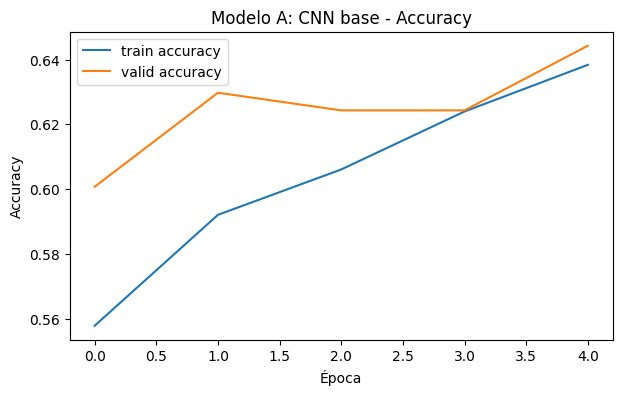

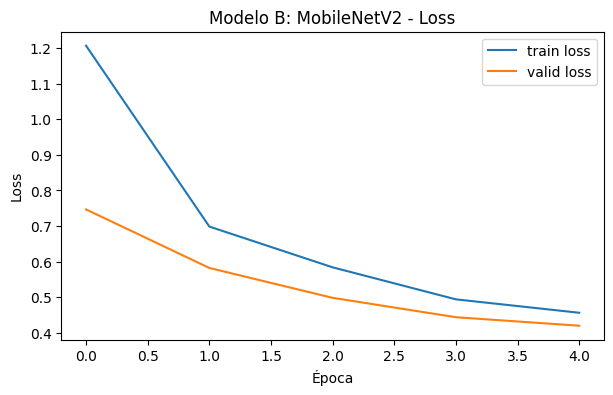

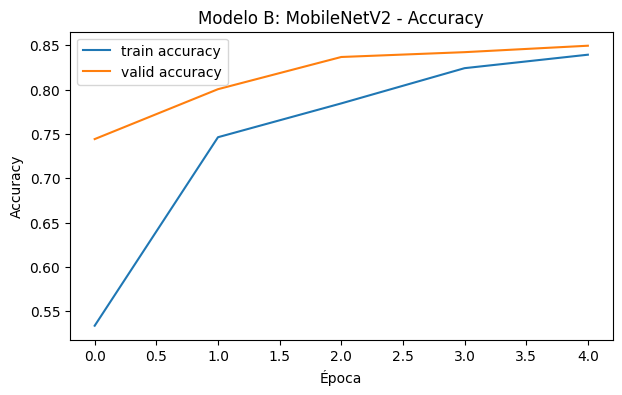

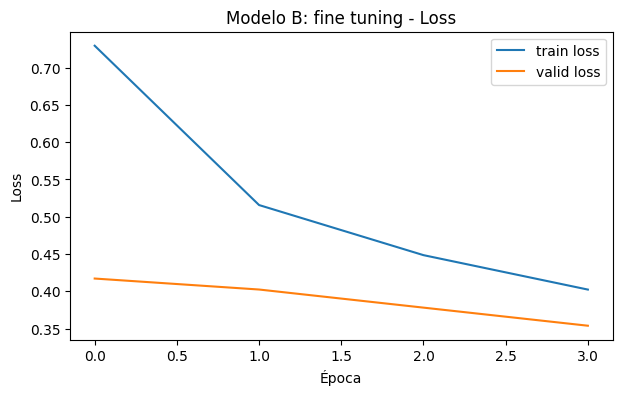

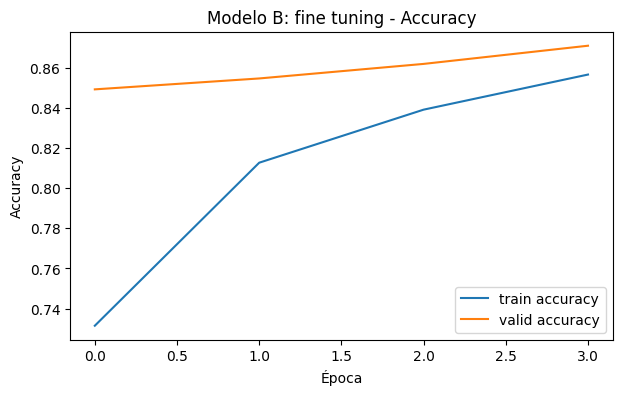

In [ ]:
def plot_history(history, title):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(7, 4))
    plt.plot(hist["loss"], label="train loss")
    plt.plot(hist["val_loss"], label="valid loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["accuracy"], label="train accuracy")
    plt.plot(hist["val_accuracy"], label="valid accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history_a, "Modelo A: CNN base")
plot_history(history_b, "Modelo B: MobileNetV2")

# Gráficas del fine tuning, si fue ejecutado
plot_history(history_b_fine, "Modelo B: fine tuning")

## 7. Evaluación comparativa en test

Se calculan las métricas principales sobre el conjunto de test:

- Accuracy
- Precision weighted
- Recall weighted
- F1-score weighted
- Matriz de confusión


In [ ]:
def get_predictions(model, dataset):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    return np.array(y_true), np.array(y_pred)

def evaluate_model(model, dataset, model_name):
    y_true, y_pred = get_predictions(model, dataset)

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "modelo": model_name,
        "accuracy": accuracy,
        "precision_weighted": precision,
        "recall_weighted": recall,
        "f1_weighted": f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

results_a = evaluate_model(model_a, test_ds, "CNN base")
results_b = evaluate_model(model_b, test_ds, "MobileNetV2 transfer learning")

metrics_table = pd.DataFrame([
    {k: v for k, v in results_a.items() if k not in ["y_true", "y_pred"]},
    {k: v for k, v in results_b.items() if k not in ["y_true", "y_pred"]}
])

metrics_table

,modelo,accuracy,precision_weighted,recall_weighted,f1_weighted
0,CNN base,0.652727,0.665564,0.652727,0.644135
1,MobileNetV2 transfer learning,0.883636,0.885709,0.883636,0.883965


In [ ]:
# Reporte de clasificación

print("Modelo A: CNN base")
print(classification_report(
    results_a["y_true"],
    results_a["y_pred"],
    target_names=class_names,
    zero_division=0
))

print("\nModelo B: MobileNetV2")
print(classification_report(
    results_b["y_true"],
    results_b["y_pred"],
    target_names=class_names,
    zero_division=0
))

Modelo A: CNN base
              precision    recall  f1-score   support

   dandelion       0.83      0.62      0.71       112
       daisy       0.62      0.68      0.65        95
      tulips       0.62      0.66      0.64       134
  sunflowers       0.61      0.92      0.74       102
       roses       0.64      0.39      0.49       107

    accuracy                           0.65       550
   macro avg       0.67      0.66      0.64       550
weighted avg       0.67      0.65      0.64       550


Modelo B: MobileNetV2
              precision    recall  f1-score   support

   dandelion       0.96      0.90      0.93       112
       daisy       0.87      0.93      0.90        95
      tulips       0.88      0.84      0.86       134
  sunflowers       0.89      0.89      0.89       102
       roses       0.82      0.88      0.85       107

    accuracy                           0.88       550
   macro avg       0.88      0.89      0.89       550
weighted avg       0.89      0.88  

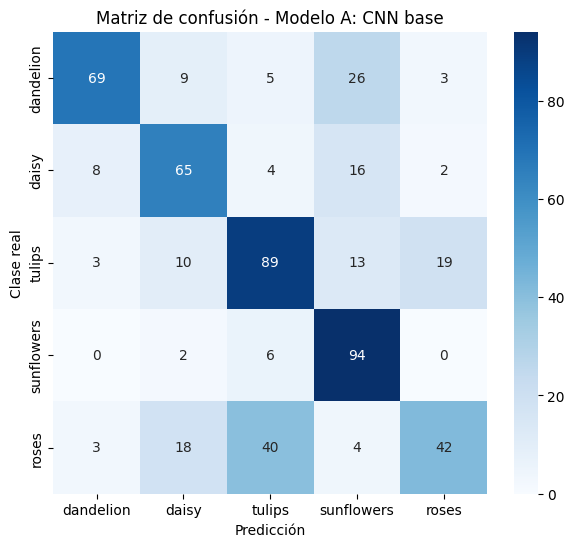

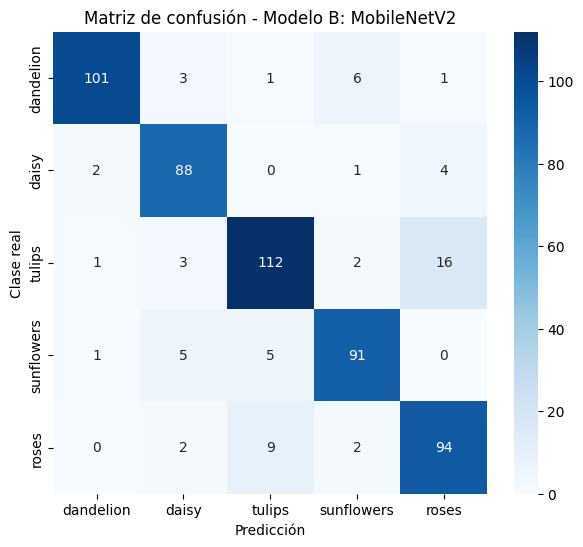

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(title)
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.show()

plot_confusion_matrix(
    results_a["y_true"],
    results_a["y_pred"],
    "Matriz de confusión - Modelo A: CNN base"
)

plot_confusion_matrix(
    results_b["y_true"],
    results_b["y_pred"],
    "Matriz de confusión - Modelo B: MobileNetV2"
)

## 8. Análisis de errores con ejemplos

Se muestran imágenes mal clasificadas por el mejor modelo.

Esto permite analizar visualmente qué clases presentan mayor confusión.


In [ ]:
# Se selecciona el modelo con mayor accuracy en test

best_model = model_b if results_b["accuracy"] >= results_a["accuracy"] else model_a
best_model_name = "MobileNetV2" if best_model == model_b else "CNN base"

print("Mejor modelo según accuracy en test:", best_model_name)

Mejor modelo según accuracy en test: MobileNetV2


In [ ]:
# Guardar imágenes, etiquetas reales y predichas del test

test_images = []
test_labels = []
test_preds = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    test_images.extend(images.numpy())
    test_labels.extend(labels.numpy())
    test_preds.extend(preds)

test_images = np.array(test_images)
test_labels = np.array(test_labels)
test_preds = np.array(test_preds)

wrong_idx = np.where(test_labels != test_preds)[0]

print("Cantidad de errores:", len(wrong_idx))
print("Cantidad total en test:", len(test_labels))

Cantidad de errores: 64
Cantidad total en test: 550


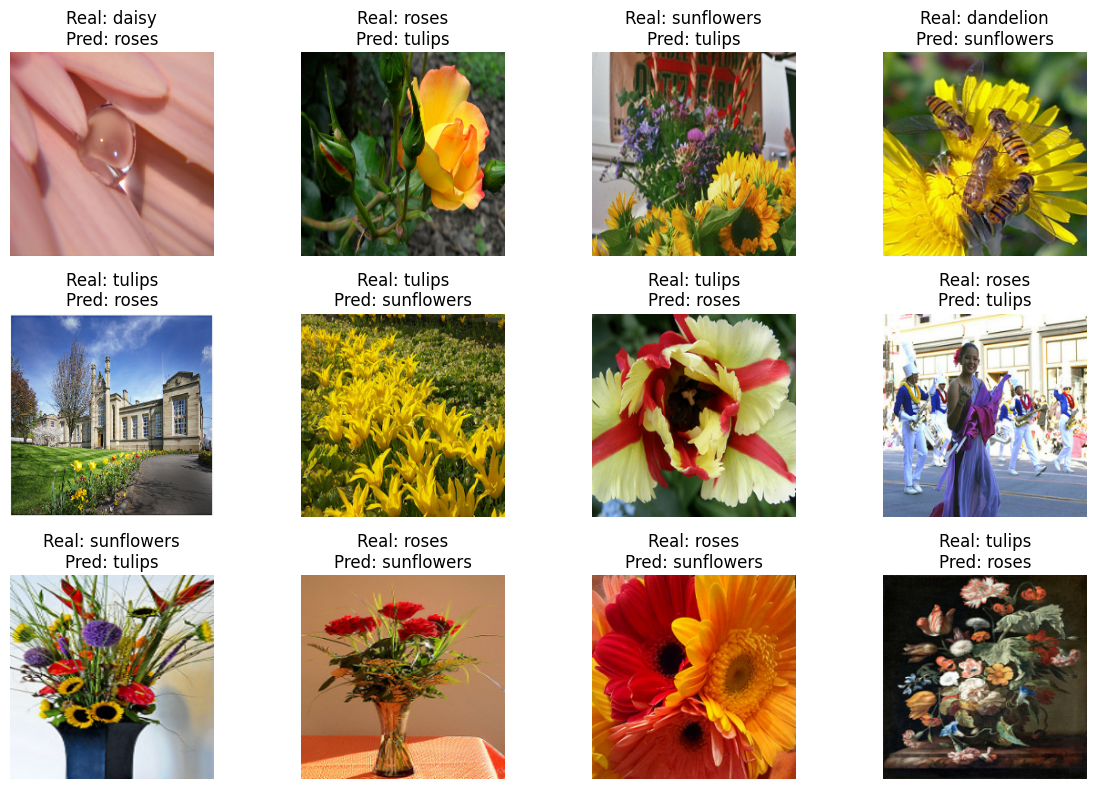

In [ ]:
# Visualización de ejemplos mal clasificados

n_errors_to_show = min(12, len(wrong_idx))

plt.figure(figsize=(12, 8))

for i, idx in enumerate(wrong_idx[:n_errors_to_show]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[idx])
    real = class_names[int(test_labels[idx])]
    pred = class_names[int(test_preds[idx])]
    plt.title(f"Real: {real}\nPred: {pred}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Errores por clase real

error_df = pd.DataFrame({
    "real": [class_names[int(x)] for x in test_labels],
    "prediccion": [class_names[int(x)] for x in test_preds],
    "error": test_labels != test_preds
})

errors_by_class = (
    error_df
    .groupby("real")["error"]
    .agg(["sum", "count"])
    .reset_index()
)

errors_by_class["tasa_error"] = errors_by_class["sum"] / errors_by_class["count"]
errors_by_class = errors_by_class.sort_values("tasa_error", ascending=False)

errors_by_class

,real,sum,count,tasa_error
4,tulips,22,134,0.164179
2,roses,13,107,0.121495
3,sunflowers,11,102,0.107843
1,dandelion,11,112,0.098214
0,daisy,7,95,0.073684


## 9. Conclusiones finales

Completar esta sección luego de ejecutar el notebook.

### Comparación general

El modelo CNN base fue entrenado desde cero, por lo que tuvo que aprender directamente las características visuales de las flores a partir de un dataset relativamente pequeño. En cambio, el modelo con MobileNetV2 partió de pesos preentrenados en ImageNet, por lo que ya contaba con filtros útiles para detectar bordes, texturas, formas y patrones visuales generales.

En general, se espera que el modelo con Transfer Learning obtenga mejor desempeño en test que la CNN base, especialmente cuando el dataset no es muy grande.

### Clase más difícil de clasificar

La clase más difícil se identifica observando:

- La matriz de confusión.
- La tabla de errores por clase.
- Los ejemplos visuales mal clasificados.

Una clase puede ser difícil porque tiene mayor variabilidad visual, fondos más complejos o similitud con otra clase.

### Overfitting

El overfitting se detecta cuando la accuracy de entrenamiento aumenta, pero la accuracy de validación se estanca o disminuye. También puede observarse cuando la loss de entrenamiento baja mientras la loss de validación sube.

Si esto ocurre, el modelo está memorizando el conjunto de entrenamiento y no generaliza bien a imágenes nuevas.

### Impacto del data augmentation

El data augmentation ayuda a generar variaciones artificiales de las imágenes de entrenamiento. Esto mejora la generalización porque el modelo aprende a reconocer una clase aunque la imagen esté rotada, ampliada o reflejada.

### Por qué el Transfer Learning suele funcionar mejor

El Transfer Learning suele funcionar mejor con pocos datos porque aprovecha representaciones visuales aprendidas previamente en datasets mucho más grandes. Por eso, el modelo no parte de cero, sino que reutiliza patrones ya aprendidos.

### Aspectos a revisar antes de producción

Antes de usar el modelo en producción habría que revisar:

- Calidad y representatividad de las imágenes.
- Balance entre clases.
- Desempeño en datos externos al dataset.
- Errores críticos del modelo.
- Tiempo de inferencia.
- Tamaño del modelo.
- Posibles sesgos.
- Necesidad de monitoreo y reentrenamiento periódico.


## Link del dataset utilizado

TensorFlow Datasets — `tf_flowers`:

https://www.tensorflow.org/datasets/catalog/tf_flowers

El dataset se carga automáticamente desde TensorFlow Datasets al entorno de Colab.
